In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
shap.initjs()

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
abalone = fetch_ucirepo(id=1) 
  
# data (as pandas dataframes) 
X = abalone.data.features 
y = abalone.data.targets 
  
# metadata 
print(abalone.metadata) 
  
# variable information 
print(abalone.variables) 


{'uci_id': 1, 'name': 'Abalone', 'repository_url': 'https://archive.ics.uci.edu/dataset/1/abalone', 'data_url': 'https://archive.ics.uci.edu/static/public/1/data.csv', 'abstract': 'Predict the age of abalone from physical measurements', 'area': 'Biology', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Tabular'], 'num_instances': 4177, 'num_features': 8, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['Rings'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C55C7W', 'creators': ['Warwick Nash', 'Tracy Sellers', 'Simon Talbot', 'Andrew Cawthorn', 'Wes Ford'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- 

In [3]:
y[X[X.columns[0]] == 'M'] 

,Rings
0,15
1,7
3,10
8,9
11,10
...,...
4170,10
4171,8
4173,10
4174,9


In [4]:
y

,Rings
0,15
1,7
2,9
3,10
4,7
...,...
4172,11
4173,10
4174,9
4175,10


Text(0, 0.5, 'Rings')

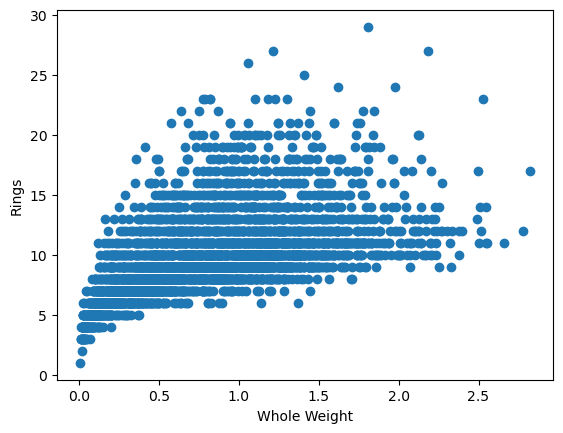

In [5]:
plt.scatter(X['Whole_weight'] , y)
plt.xlabel("Whole Weight")
plt.ylabel("Rings")

{'whiskers': [<matplotlib.lines.Line2D at 0x23f234649e0>,
 'caps': [<matplotlib.lines.Line2D at 0x23f23464fe0>,
 'boxes': [<matplotlib.lines.Line2D at 0x23f234646b0>],
 'medians': [<matplotlib.lines.Line2D at 0x23f23465580>],
 'fliers': [<matplotlib.lines.Line2D at 0x23f23465880>],
 'means': []}

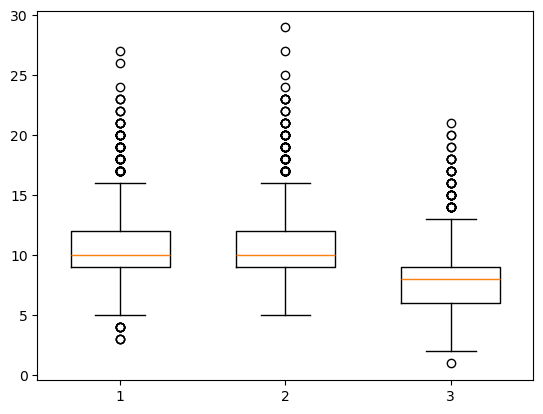

In [6]:
plt.boxplot(y.loc[X[X["Sex"] == 'M'].index] , positions=[1], widths=0.6)
plt.boxplot(y.loc[X[X["Sex"] == 'F'].index] , positions=[2], widths=0.6)
plt.boxplot(y.loc[X[X["Sex"] == 'I'].index] , positions=[3], widths=0.6)

<Axes: >

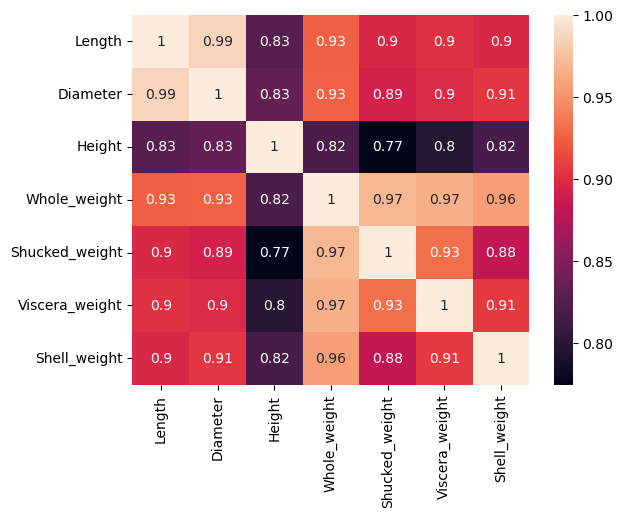

In [7]:
sns.heatmap(X.drop(columns=['Sex']).corr(), annot=True)

In [8]:
X["sexM"] = X["Sex"].apply(lambda x: 1 if x == 'M' else 0)
X["sexF"] = X["Sex"].apply(lambda x: 1 if x == 'F' else 0)
X["sexI"] = X["Sex"].apply(lambda x: 1 if x == 'I' else 0)

X.drop(columns=['Sex'], inplace=True)

In [9]:
X.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,sexM,sexF,sexI
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,1,0,0
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,1,0,0
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,0,1,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,1,0,0
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,0,0,1


In [10]:
model = xgb.XGBRegressor(objective='reg:squarederror')
model.fit(X, y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

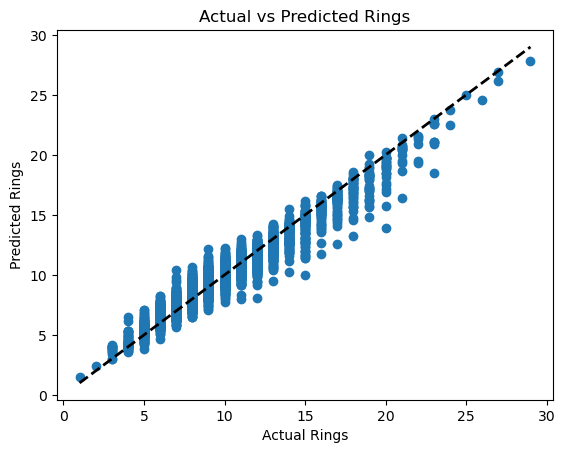

In [11]:
y_pred = model.predict(X)

plt.Figure(figsize=(10, 6))
plt.scatter(y, y_pred)
plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Actual vs Predicted Rings")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.show()


In [12]:
explainer = shap.Explainer(model)
shap_values = explainer(X)
# shap.summary_plot(shap_values, X)


In [13]:
np.shape(shap_values.values)

(4177, 10)

In [19]:
shap_values

.values =
array([[ 6.43719554e-01,  5.12253046e-01,  7.32342601e-01, ...,
         3.72212023e-01, -3.15770730e-02,  3.60005170e-01],
       [-4.25514728e-01, -4.93034780e-01, -3.12807053e-01, ...,
         5.83391711e-02, -5.76708689e-02,  2.93503642e-01],
       [-1.73290879e-01,  1.36856223e-04,  9.01151076e-02, ...,
         1.02404086e-02,  1.32069007e-01,  1.68871522e-01],
       ...,
       [ 1.04510695e-01,  1.62028223e-01,  9.14546907e-01, ...,
        -3.85120809e-02,  1.03055565e-02,  3.79706956e-02],
       [-3.27949703e-01,  1.62253350e-01,  5.19407056e-02, ...,
         2.33049467e-02,  3.39937508e-02,  3.50896344e-02],
       [-5.04229404e-02,  3.87722969e-01,  1.89526290e-01, ...,
         1.05029278e-01,  2.46347692e-02,  4.74777296e-02]], dtype=float32)

.base_values =
array([9.932957, 9.932957, 9.932957, ..., 9.932957, 9.932957, 9.932957],
      dtype=float32)

.data =
array([[0.455, 0.365, 0.095, ..., 1.   , 0.   , 0.   ],
       [0.35 , 0.265, 0.09 , ..., 1.   , 0.

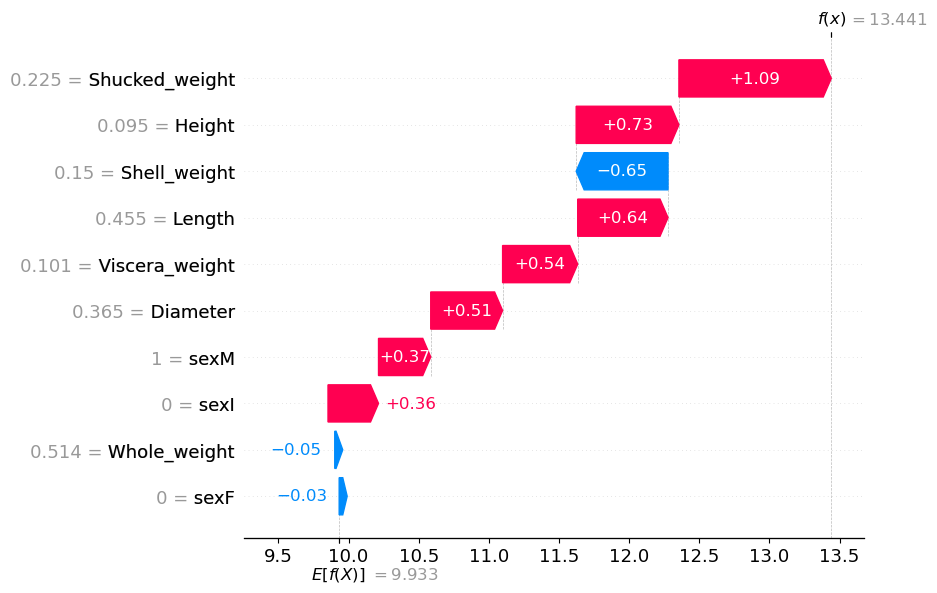

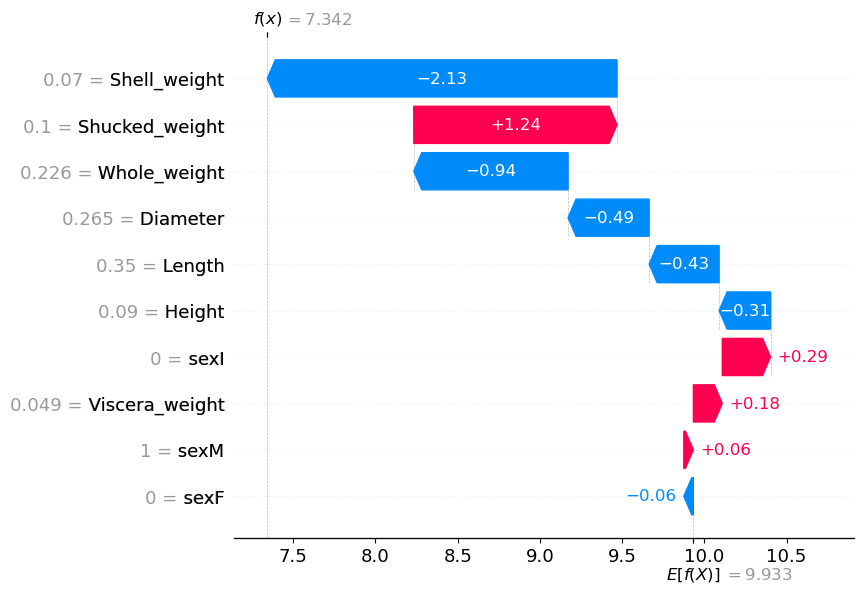

In [ ]:
shap.waterfall_plot(shap_values[0])
# shap.waterfall_plot(shap_values[1])


In [22]:
shap.force_plot(shap_values[0:100])

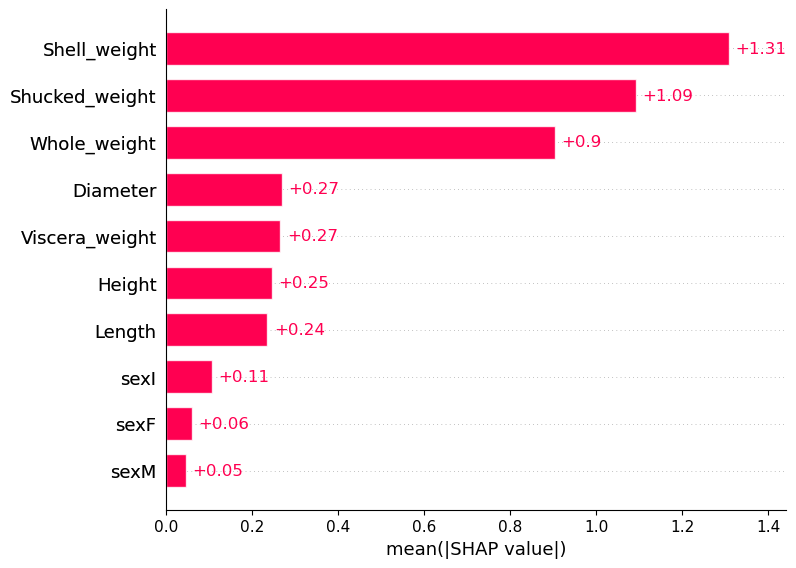

In [25]:
shap.plots.bar(shap_values)

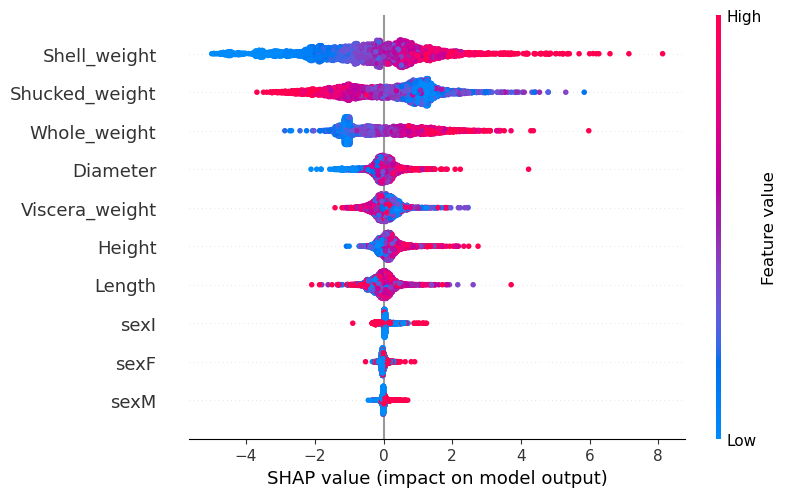

In [26]:
shap.plots.beeswarm(shap_values)

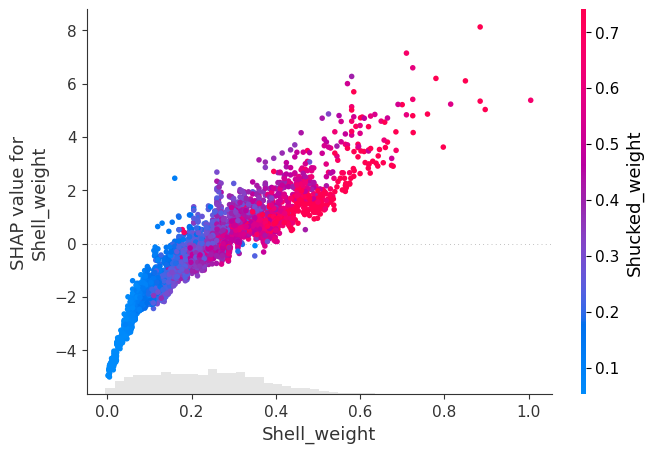

In [29]:
shap.plots.scatter(shap_values[: , "Shell_weight"], color=shap_values)

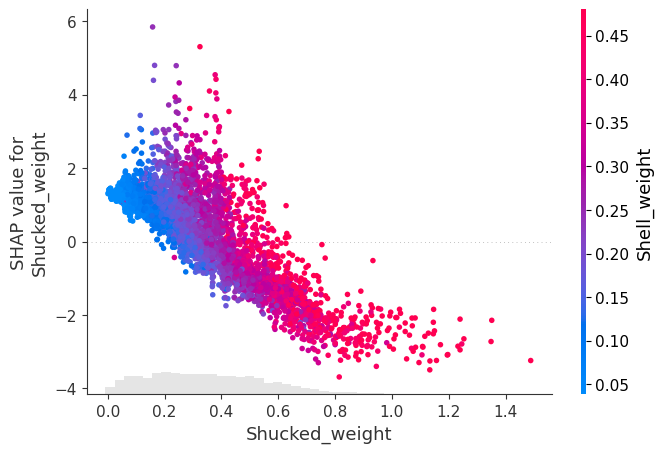

In [30]:
shap.plots.scatter(shap_values[: , "Shucked_weight"], color=shap_values)